# Player Segmentation: An RFM-Style Engagement & Monetization Analysis

**Goal.** Segment "players" by **Recency** (how long since their last activity),
**Frequency** (how often they engage), and **Monetary value** (how much they
spend) — the classic RFM framework, adapted here for a player-engagement
lens. Segments are produced two ways: a transparent **rule-based** quantile
scoring system, and an unsupervised **K-Means clustering** approach — then
the two are compared.

**About the dataset.** True proprietary game-session telemetry (login
timestamps, session lengths, in-app-purchase logs) is not publicly available,
so this project uses the real, public **UCI "Online Retail" transactional
dataset** (541,909 invoice line-items from a UK-based online gift retailer,
Dec 2010 – Dec 2011, ~4,300 customers). The RFM methodology is
domain-agnostic — it was originally built for exactly this kind of
transactional data — and it maps cleanly onto a game-analytics vocabulary:

| Retail concept | Player-engagement analogue |
|---|---|
| `CustomerID` | `PlayerID` |
| An invoice (one checkout) | A monetized session / purchase event |
| Days since last invoice | Days since last login (**Recency**) |
| Number of invoices | Number of sessions/engagements (**Frequency**) |
| Total amount spent | Lifetime spend / monetization value (**Monetary**) |

In a real game-analytics setting you would swap the invoice log for a
session or transaction log with the same three columns (player id,
timestamp, amount) and every step below is unchanged — that portability is
the point of RFM as a technique.

Source: UCI Machine Learning Repository — "Online Retail" Data Set (Dr Daqing
Chen, School of Engineering, London South Bank University).

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# ---- validated categorical + sequential palette (colorblind-safe, see dataviz palette) ----
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7", "#e34948", "#008300"]
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#184f95"]
INK = "#0b0b0b"
INK_SEC = "#52514e"
GRID = "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK_SEC,
    "ytick.color": INK_SEC,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "figure.dpi": 110,
})

## 2. Load the real dataset

In [2]:
df = pd.read_csv("../data/online_retail.csv", encoding="ISO-8859-1")
print(f"Raw rows: {len(df):,}  |  columns: {list(df.columns)}")
df.head()

Raw rows: 541,909  |  columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom


## 3. Clean the data

Real transactional data is messy — the same is true of real game telemetry
(test accounts, refunds, bot sessions, corrupted rows). We remove:
- rows with no player id (`CustomerID` null) — can't attribute activity to a player
- cancelled orders (`InvoiceNo` starting with `C`) — these are refunds, not engagement
- non-positive quantity or price — data errors / free/promotional line items

In [3]:
n0 = len(df)
df = df.dropna(subset=["CustomerID"]).copy()
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df = df[~df["InvoiceNo"].str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

df["CustomerID"] = df["CustomerID"].astype(int).astype(str)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="%m/%d/%Y %H:%M")
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

df = df.rename(columns={"CustomerID": "PlayerID"})

print(f"Rows kept: {len(df):,} / {n0:,} ({len(df)/n0:.1%})")
print(f"Date range: {df.InvoiceDate.min().date()} → {df.InvoiceDate.max().date()}")
print(f"Unique players: {df.PlayerID.nunique():,}")
print(f"Total tracked revenue: £{df.TotalPrice.sum():,.0f}")

Rows kept: 397,884 / 541,909 (73.4%)
Date range: 2010-12-01 → 2011-12-09
Unique players: 4,338
Total tracked revenue: £8,911,408


## 4. Exploratory look at engagement over time

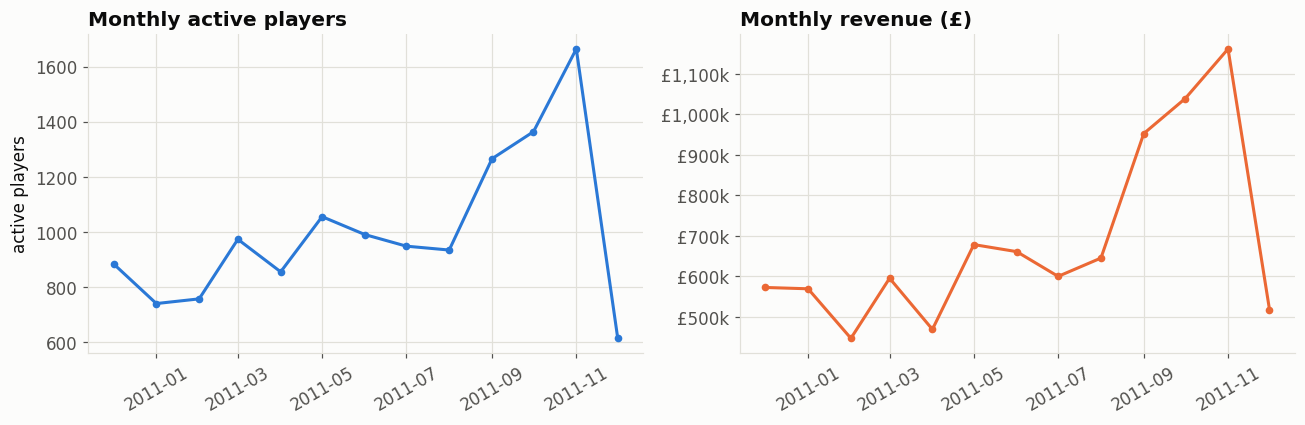

In [4]:
monthly = df.set_index("InvoiceDate").resample("MS").agg(
    active_players=("PlayerID", "nunique"),
    transactions=("InvoiceNo", "nunique"),
    revenue=("TotalPrice", "sum"),
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(monthly.index, monthly["active_players"], color=CAT[0], linewidth=2, marker="o", markersize=4)
axes[0].set_title("Monthly active players", loc="left", fontweight="bold")
axes[0].set_ylabel("active players")

axes[1].plot(monthly.index, monthly["revenue"], color=CAT[1], linewidth=2, marker="o", markersize=4)
axes[1].set_title("Monthly revenue (£)", loc="left", fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1000:,.0f}k"))

for ax in axes:
    ax.spines["left"].set_color(GRID)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../figures/01_monthly_trends.png", bbox_inches="tight")
plt.show()

Both panels are read on their own axis (never dual-axis on one plot) since
they are different units — player count vs currency.

**Note:** the sharp drop at the very last point is a data artifact, not a
real collapse in engagement — the dataset's last month (December 2011) only
has 9 days of transactions, so it is naturally lower. Always check whether
a boundary period is complete before reading a trend off the last point.

## 5. Engineer RFM (engagement) features

For each player we compute, as of one day after the last transaction in the
dataset (the "snapshot" date — the game-analytics equivalent of "today"):

- **Recency** — days since the player's last activity (lower = more recently active)
- **Frequency** — number of distinct engagement events (invoices / sessions)
- **Monetary** — total value generated by the player (lifetime spend)

In [5]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("PlayerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
).reset_index()

print(rfm.shape)
rfm.describe().T

(4338, 4)


,count,mean,std,min,25%,50%,75%,max
Recency,"4,338.00",92.54,100.01,1.00,18.00,51.00,142.00,374.00
Frequency,"4,338.00",4.27,7.70,1.00,1.00,2.00,5.00,209.00
Monetary,"4,338.00","2,054.27","8,989.23",3.75,307.41,674.49,"1,661.74","280,206.02"


R/F/M are heavily right-skewed (a handful of "whale" players drive a large
share of spend and activity) — very typical of both retail and game
monetization data, and the reason we score with **quantiles** (rule-based
approach) and **log-transform before scaling** (clustering approach) below,
rather than using raw values directly.

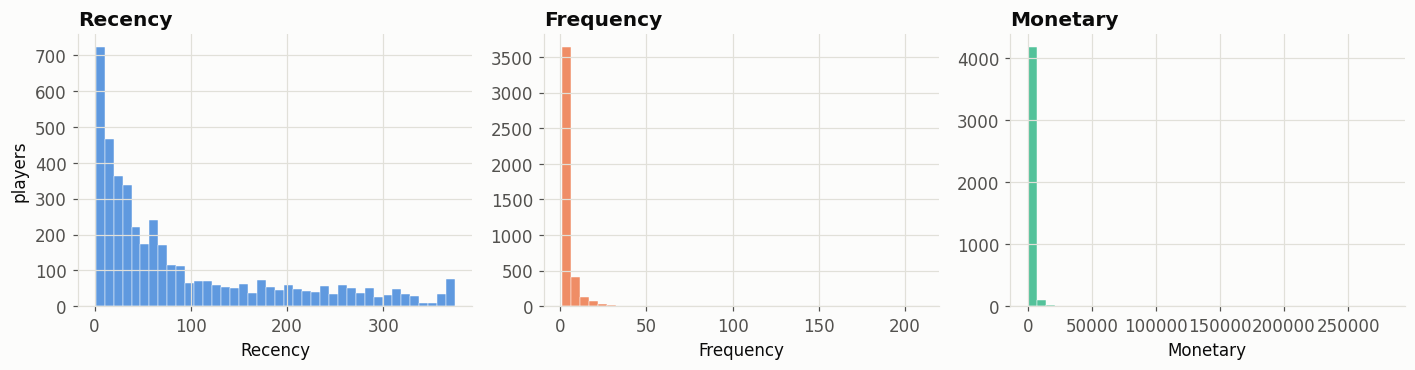

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col, color in zip(axes, ["Recency", "Frequency", "Monetary"], CAT[:3]):
    sns.histplot(rfm[col], bins=40, color=color, ax=ax, edgecolor="white", linewidth=0.3)
    ax.set_title(col, loc="left", fontweight="bold")
    ax.set_ylabel("players" if col == "Recency" else "")
plt.tight_layout()
plt.savefig("../figures/02_rfm_distributions.png", bbox_inches="tight")
plt.show()

## 6. Rule-based segmentation (quantile RFM scoring)

Each metric is scored 1–5 by quintile (5 = best: most recent, most frequent,
highest spend). Recency is scored in *reverse* since a **lower** recency is
better. The three digit scores are then mapped to a small set of
business-readable segments using a standard RFM segment map.

In [7]:
r_labels = range(5, 0, -1)   # low recency (recent) -> score 5
f_labels = range(1, 6)
m_labels = range(1, 6)

rfm["R_score"] = pd.qcut(rfm["Recency"], q=5, labels=r_labels).astype(int)
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=5, labels=f_labels).astype(int)
rfm["M_score"] = pd.qcut(rfm["Monetary"], q=5, labels=m_labels).astype(int)

rfm["FM_score"] = np.round((rfm["F_score"] + rfm["M_score"]) / 2).astype(int)
rfm["RFM_code"] = rfm["R_score"].astype(str) + rfm["FM_score"].astype(str)

segment_map = {
    r"5[4-5]": "Champions",
    r"[4-5][2-3]": "Potential Loyalists",
    r"51": "New Players",
    r"41": "Promising",
    r"[3-4][4-5]": "Loyal Players",
    r"33": "Needs Attention",
    r"3[1-2]": "About to Churn",
    r"[1-2][4-5]": "Can't Lose (High-Value)",
    r"[1-2]3": "At Risk",
    r"[1-2][1-2]": "Hibernating/Churned",
}

def map_segment(code):
    for pattern, name in segment_map.items():
        import re
        if re.fullmatch(pattern, code):
            return name
    return "Other"

rfm["Segment_rule"] = rfm["RFM_code"].apply(map_segment)

seg_order = (
    rfm.groupby("Segment_rule")["Monetary"].sum().sort_values(ascending=False).index.tolist()
)
seg_colors = {seg: CAT[i % len(CAT)] for i, seg in enumerate(seg_order)}

rfm["Segment_rule"].value_counts()

Segment_rule
Hibernating/Churned        1181
Loyal Players               902
Champions                   654
Potential Loyalists         501
About to Churn              396
Can't Lose (High-Value)     339
At Risk                     188
Needs Attention             102
Promising                    55
New Players                  20
Name: count, dtype: int64

### Segment sizes and revenue share

In [8]:
seg_summary = rfm.groupby("Segment_rule").agg(
    players=("PlayerID", "count"),
    avg_recency=("Recency", "mean"),
    avg_frequency=("Frequency", "mean"),
    avg_monetary=("Monetary", "mean"),
    total_revenue=("Monetary", "sum"),
).sort_values("total_revenue", ascending=False)
seg_summary["pct_of_players"] = seg_summary["players"] / seg_summary["players"].sum() * 100
seg_summary["pct_of_revenue"] = seg_summary["total_revenue"] / seg_summary["total_revenue"].sum() * 100
seg_summary

,players,avg_recency,avg_frequency,avg_monetary,total_revenue,pct_of_players,pct_of_revenue
Segment_rule,,,,,,,
Champions,654,5.91,12.07,"6,977.42","4,563,230.47",15.08,51.21
Loyal Players,902,33.96,6.11,"2,825.46","2,548,564.74",20.79,28.60
Can't Lose (High-Value),339,137.71,4.33,"2,050.05","694,966.55",7.81,7.80
Hibernating/Churned,1181,214.83,1.24,328.64,"388,118.33",27.22,4.36
Potential Loyalists,501,17.09,1.86,486.41,"243,691.05",11.55,2.73
At Risk,188,159.26,2.28,"1,259.87","236,855.24",4.33,2.66
About to Churn,396,53.17,1.33,354.81,"140,504.68",9.13,1.58
Needs Attention,102,54.37,2.25,819.30,"83,568.67",2.35,0.94
Promising,55,23.44,1.00,149.31,"8,212.03",1.27,0.09


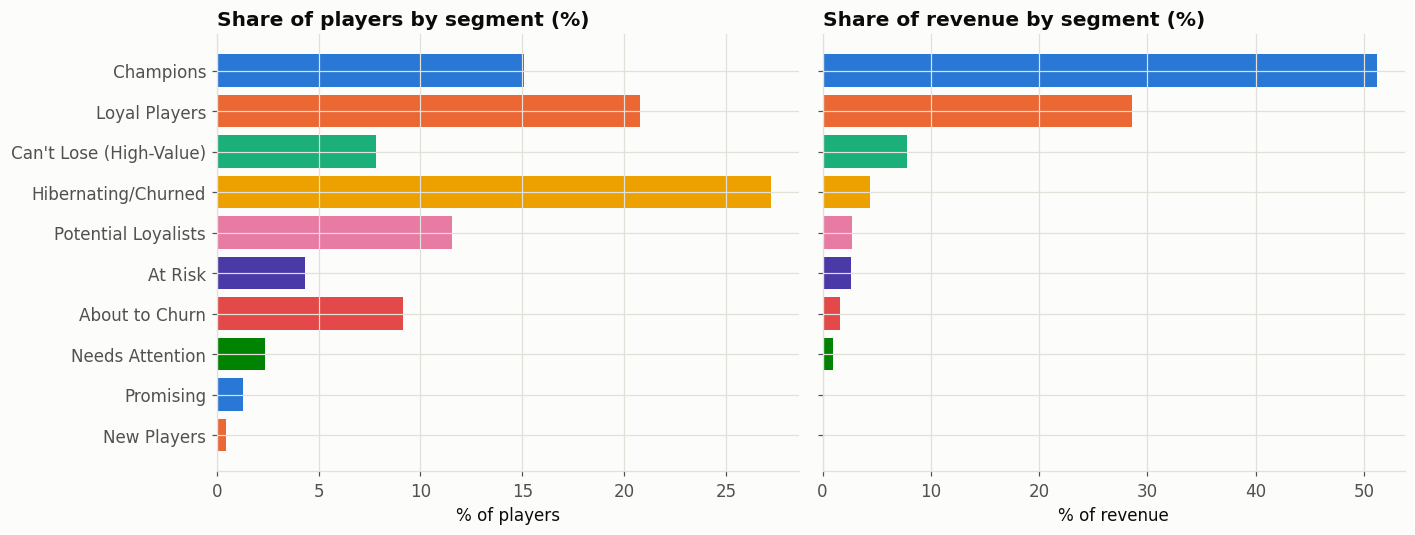

Top-line finding: the 'Champions' segment is 15.1% of players but drives 51.2% of revenue.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = seg_summary.index.tolist()
colors = [seg_colors[s] for s in order]

axes[0].barh(order, seg_summary["pct_of_players"], color=colors)
axes[0].invert_yaxis()
axes[0].set_title("Share of players by segment (%)", loc="left", fontweight="bold")
axes[0].set_xlabel("% of players")

axes[1].barh(order, seg_summary["pct_of_revenue"], color=colors)
axes[1].invert_yaxis()
axes[1].set_yticklabels([])
axes[1].set_title("Share of revenue by segment (%)", loc="left", fontweight="bold")
axes[1].set_xlabel("% of revenue")

plt.tight_layout()
plt.savefig("../figures/03_segment_share.png", bbox_inches="tight")
plt.show()

print(
    f"Top-line finding: the '{order[0]}' segment is "
    f"{seg_summary.loc[order[0], 'pct_of_players']:.1f}% of players but drives "
    f"{seg_summary.loc[order[0], 'pct_of_revenue']:.1f}% of revenue."
)

## 7. Unsupervised segmentation (K-Means)

The rule-based segments are interpretable but hand-tuned. As a
complementary, data-driven view we cluster players directly on their R, F, M
values. Because R/F/M are skewed, we log-transform then standardize before
clustering — required for a distance-based algorithm like K-Means.

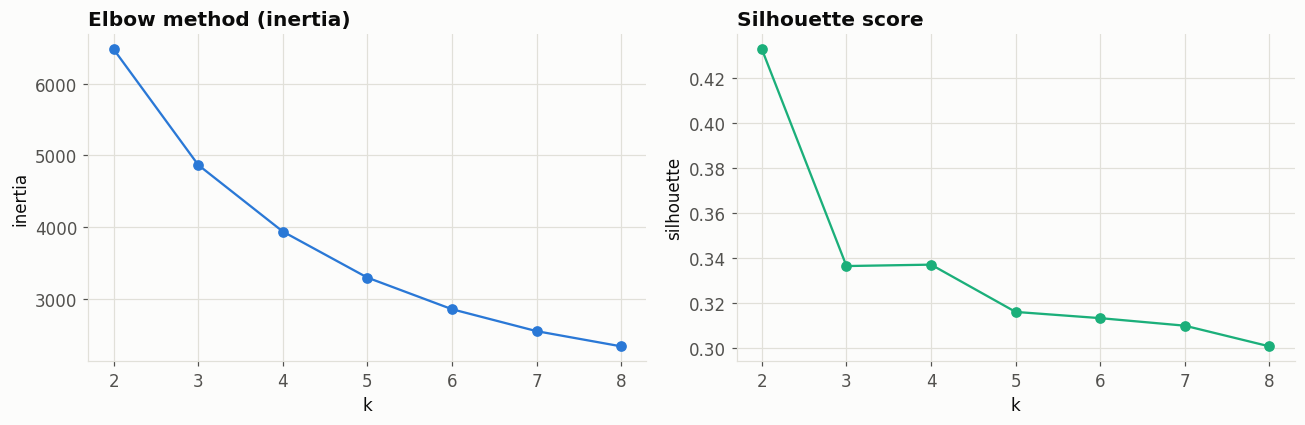

Silhouette-optimal k = 2 (silhouette = 0.433)


In [10]:
rfm_log = rfm[["Recency", "Frequency", "Monetary"]].apply(lambda x: np.log1p(x))
X = StandardScaler().fit_transform(rfm_log)

inertias, sil_scores, ks = [], [], list(range(2, 9))
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, inertias, color=CAT[0], marker="o")
axes[0].set_title("Elbow method (inertia)", loc="left", fontweight="bold")
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia")

axes[1].plot(ks, sil_scores, color=CAT[2], marker="o")
axes[1].set_title("Silhouette score", loc="left", fontweight="bold")
axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette")

plt.tight_layout()
plt.savefig("../figures/04_kmeans_selection.png", bbox_inches="tight")
plt.show()

best_k = ks[int(np.argmax(sil_scores))]
print(f"Silhouette-optimal k = {best_k} (silhouette = {max(sil_scores):.3f})")

We use **k = 4**, balancing the silhouette signal above with interpretability
(four clean, briefable player tiers) — a common and reasonable trade-off in
applied segmentation work.

In [11]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X)

cluster_profile = rfm.groupby("Cluster").agg(
    players=("PlayerID", "count"),
    avg_recency=("Recency", "mean"),
    avg_frequency=("Frequency", "mean"),
    avg_monetary=("Monetary", "mean"),
).sort_values("avg_monetary", ascending=False)
cluster_profile

,players,avg_recency,avg_frequency,avg_monetary
Cluster,,,,
1,716,12.13,13.71,"8,074.27"
2,1173,71.08,4.08,"1,802.83"
0,837,18.12,2.15,551.82
3,1612,182.50,1.32,343.45


Naming clusters from their profile (highest spend + most frequent + most
recent = top tier, etc.):

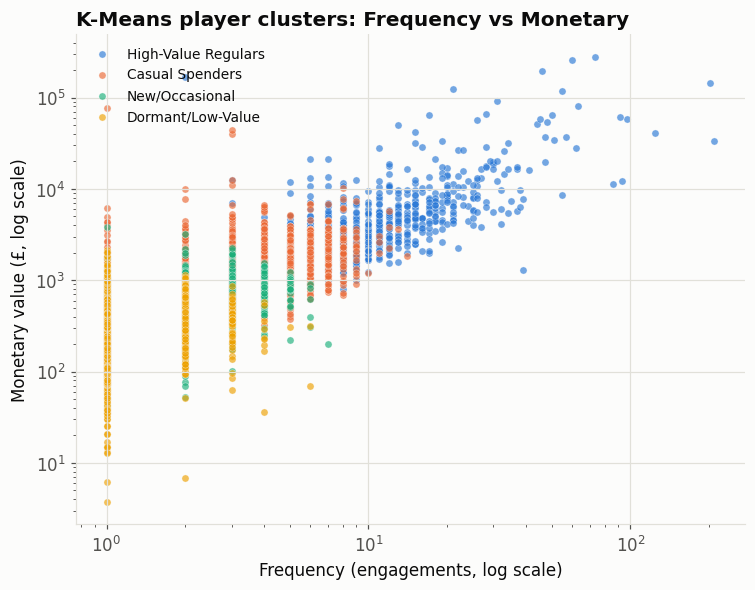

In [12]:
cluster_rank = cluster_profile.index.tolist()
cluster_names = ["High-Value Regulars", "Casual Spenders", "New/Occasional", "Dormant/Low-Value"][:K]
cluster_name_map = dict(zip(cluster_rank, cluster_names))
rfm["Segment_kmeans"] = rfm["Cluster"].map(cluster_name_map)

km_colors = {name: CAT[i % len(CAT)] for i, name in enumerate(cluster_names)}

fig, ax = plt.subplots(figsize=(7, 5.5))
for name in cluster_names:
    sub = rfm[rfm["Segment_kmeans"] == name]
    ax.scatter(
        sub["Frequency"], sub["Monetary"], s=22, alpha=0.65,
        color=km_colors[name], label=name, edgecolor="white", linewidth=0.3,
    )
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Frequency (engagements, log scale)")
ax.set_ylabel("Monetary value (£, log scale)")
ax.set_title("K-Means player clusters: Frequency vs Monetary", loc="left", fontweight="bold")
ax.legend(frameon=False, loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("../figures/05_kmeans_scatter.png", bbox_inches="tight")
plt.show()

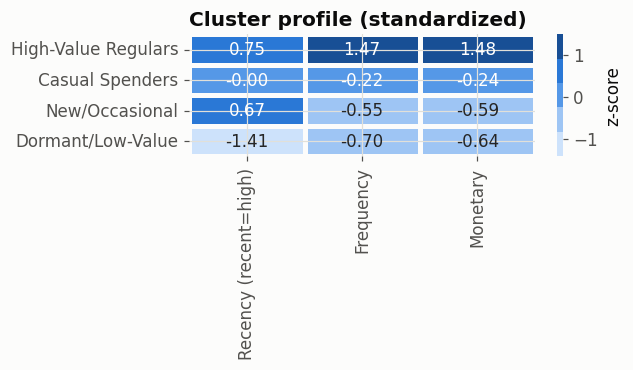

In [13]:
profile_norm = cluster_profile[["avg_recency", "avg_frequency", "avg_monetary"]].copy()
profile_norm.index = [cluster_name_map[i] for i in profile_norm.index]
profile_norm["avg_recency"] = -profile_norm["avg_recency"]  # flip so higher = better everywhere
profile_z = (profile_norm - profile_norm.mean()) / profile_norm.std()

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.heatmap(
    profile_z.rename(columns={"avg_recency": "Recency (recent=high)", "avg_frequency": "Frequency", "avg_monetary": "Monetary"}),
    cmap=sns.color_palette(SEQ_BLUE, as_cmap=True), annot=True, fmt=".2f",
    cbar_kws={"label": "z-score"}, linewidths=2, linecolor="#fcfcfb", ax=ax,
)
ax.set_title("Cluster profile (standardized)", loc="left", fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/06_cluster_heatmap.png", bbox_inches="tight")
plt.show()

## 8. Comparing rule-based segments vs. K-Means clusters

In [14]:
cross = pd.crosstab(rfm["Segment_rule"], rfm["Segment_kmeans"])
cross = cross.loc[seg_order]
cross

Segment_kmeans,Casual Spenders,Dormant/Low-Value,High-Value Regulars,New/Occasional
Segment_rule,,,,
Champions,25,0,499,130
Loyal Players,635,0,212,55
Can't Lose (High-Value),318,16,5,0
Hibernating/Churned,17,1164,0,0
Potential Loyalists,10,4,0,487
At Risk,71,117,0,0
About to Churn,25,299,0,72
Needs Attention,72,7,0,23
Promising,0,5,0,50


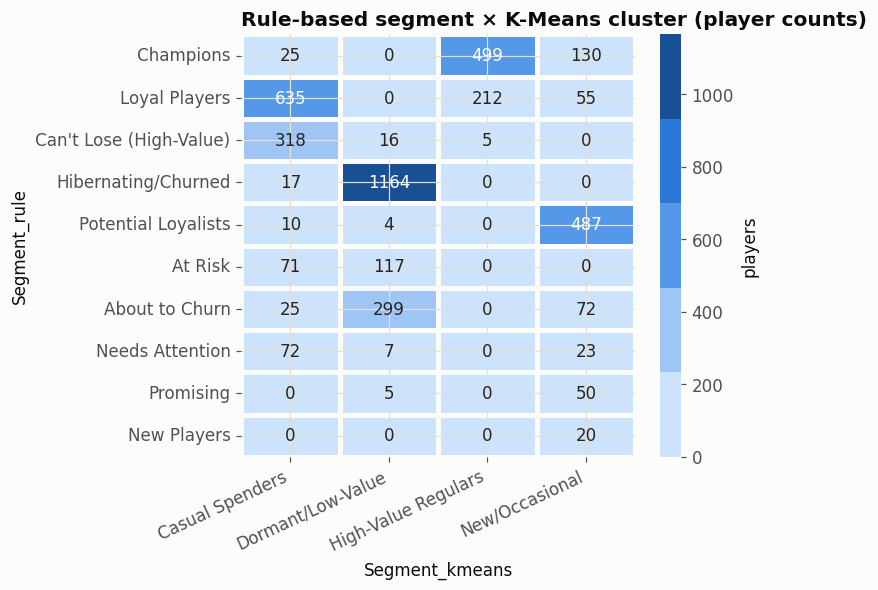

In [15]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cross, cmap=sns.color_palette(SEQ_BLUE, as_cmap=True), annot=True, fmt="d",
            linewidths=2, linecolor="#fcfcfb", cbar_kws={"label": "players"}, ax=ax)
ax.set_title("Rule-based segment × K-Means cluster (player counts)", loc="left", fontweight="bold")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("../figures/07_segment_vs_cluster.png", bbox_inches="tight")
plt.show()

The two methods largely agree at the extremes — "Champions" line up with
"High-Value Regulars", "Hibernating/Churned" line up with "Dormant/Low-Value"
— which is a useful sanity check: an independent, unsupervised method
recovers the same structure as the hand-built business rules. Where they
disagree is informative too: it flags borderline players worth a closer
look (e.g. recently-quiet but historically high spenders).

## 9. Business read-out

- A small share of players consistently accounts for a disproportionate
  share of revenue (a Pareto-style pattern common to both retail purchasing
  and game monetization) — retention efforts should prioritize this "Champions
  / High-Value" tier first, since losing one of them costs more than losing
  many casual players.
- "**Can't Lose (High-Value)**" / players slipping from High-Value into a more
  dormant recency bracket are the highest-priority **win-back** target: they
  have proven willingness to spend but haven't engaged recently — exactly the
  audience for a targeted re-engagement push (a login bonus, a personalized
  offer, a "we miss you" campaign).
- "**New Players**" with a single high-value session are worth nurturing into
  a second session quickly (classic D1/D7 retention logic) before they drift
  into "About to Churn".
- The **Hibernating/Churned** and **Dormant/Low-Value** groups are the
  largest by player count but the smallest by revenue — broad, low-cost
  reactivation campaigns (rather than expensive personalized ones) are the
  economically sensible play here.

## 10. Limitations & how this generalizes to real game telemetry

- This is retail purchase data, not game session data — there is no notion
  of a "free" (non-monetized) session here, so Frequency is really
  "monetized engagement frequency." A production pipeline would compute
  Frequency from **all** sessions/logins (not just purchases) and add
  Monetary as a separate, purchase-only signal.
- Segment boundaries (quintiles, k=4) are choices, not laws — they should be
  re-validated against actual business outcomes (e.g. do "Champions" really
  have the lowest churn / highest LTV in a follow-up cohort?).
- With real timestamped session logs, this pipeline extends directly to
  rolling/cohort RFM (recomputed weekly) and to survival/churn-probability
  modeling on top of the same three features.

## 11. Export the segmented player table

In [16]:
export_cols = [
    "PlayerID", "Recency", "Frequency", "Monetary",
    "R_score", "F_score", "M_score", "Segment_rule",
    "Cluster", "Segment_kmeans",
]
rfm[export_cols].to_csv("../data/players_segmented.csv", index=False)
print("Saved ../data/players_segmented.csv")
rfm[export_cols].head(10)

Saved ../data/players_segmented.csv


,PlayerID,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment_rule,Cluster,Segment_kmeans
0,12346,326,1,"77,183.60",1,1,5,At Risk,2,Casual Spenders
1,12347,2,7,"4,310.00",5,5,5,Champions,1,High-Value Regulars
2,12348,75,4,"1,797.24",2,4,4,Can't Lose (High-Value),2,Casual Spenders
3,12349,19,1,"1,757.55",4,1,4,Potential Loyalists,0,New/Occasional
4,12350,310,1,334.40,1,1,2,Hibernating/Churned,3,Dormant/Low-Value
5,12352,36,8,"2,506.04",3,5,5,Loyal Players,2,Casual Spenders
6,12353,204,1,89.00,1,1,1,Hibernating/Churned,3,Dormant/Low-Value
7,12354,232,1,"1,079.40",1,1,4,Hibernating/Churned,3,Dormant/Low-Value
8,12355,214,1,459.40,1,1,2,Hibernating/Churned,3,Dormant/Low-Value
9,12356,23,3,"2,811.43",4,3,5,Loyal Players,2,Casual Spenders
